# 1막. 문제 제기 - EDA

이 노트북의 목적은 두 가지다.

1. `is_fraud` 클래스 불균형이 얼마나 심한지 확인하고, 이것이 왜 accuracy를 무의미한 지표로 만드는지 짚는다.
2. **사기 거래와 정상 거래의 금액(`amt`) 분포가 다른지 통계적으로 검증한다.** 이 결과가 이후 3막(모델링), 4막(비용 최적화)에서 "FN 비용과 FP 비용은 성격이 다르다"는 주장의 근거가 된다.

즉 이 노트북은 EDA 자체가 목적이 아니라, **`threshold = 0.5`가 왜 이 데이터에 부적절한 기본값인지에 대한 증거를 만드는 단계**다.

## Section 0. 환경설정

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

# 시스템에 설치된 한글 폰트를 우선순위대로 탐색해 적용 (없으면 기본 폰트 유지)
# 주의: sns.set_style()이 rcParams의 font.family를 초기화하므로 반드시 그 다음에 설정해야 한다.
korean_font_candidates = [
    "AppleGothic",
    "Apple SD Gothic Neo",
    "Noto Sans CJK KR",
    "NanumGothic",
    "Malgun Gothic",
]
available_fonts = {f.name for f in fm.fontManager.ttflist}
for font_name in korean_font_candidates:
    if font_name in available_fonts:
        plt.rcParams["font.family"] = font_name
        break
else:
    warnings.warn("한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있습니다.")

plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", None)
print(f"적용된 폰트: {plt.rcParams['font.family']}")

적용된 폰트: ['AppleGothic']


In [2]:
df = pd.read_csv("../data/credit.csv")
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0


In [3]:
print(f"shape: {df.shape}")
df.dtypes

shape: (1296675, 24)


Unnamed: 0                 int64
trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
merch_zipcode            float64
dtype: object

In [4]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

merch_zipcode    195973
dtype: int64

## Section 1. 사기 비율 확인

In [5]:
fraud_counts = df["is_fraud"].value_counts()
fraud_ratio = df["is_fraud"].value_counts(normalize=True) * 100

summary = pd.DataFrame({"count": fraud_counts, "ratio(%)": fraud_ratio.round(3)})
summary.index = summary.index.map({0: "정상(0)", 1: "사기(1)"})
summary

,count,ratio(%)
is_fraud,,
정상(0),1289169,99.421
사기(1),7506,0.579


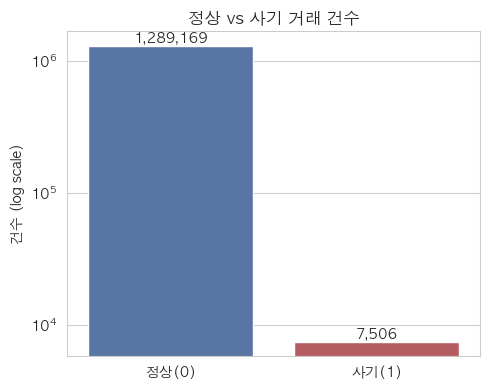

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=summary.index, y=summary["count"], hue=summary.index, palette=["#4C72B0", "#C44E52"], legend=False, ax=ax)
ax.set_yscale("log")
ax.set_ylabel("건수 (log scale)")
ax.set_xlabel("")
ax.set_title("정상 vs 사기 거래 건수")

for i, v in enumerate(summary["count"]):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

사기 거래는 전체의 0.58%(7,506건 / 1,296,675건)에 불과해, 전형적인 극단적 클래스 불균형 데이터다.

**이 비율이 왜 문제가 되는가?**

이 데이터에서 모든 거래를 "정상"이라고만 예측해도 accuracy는 약 99.4%가 나온다. 즉 accuracy는 아무것도 하지 않아도 높게 나오는 지표이며, 이 프로젝트가 실제로 줄이려는 대상인 "놓친 사기(FN)"와 "오탐(FP)"을 전혀 반영하지 못한다.

따라서 이후 노트북에서는 accuracy 대신 precision·recall·PR-AUC, 그리고 궁극적으로는 4막에서 다룰 **비용 관점의 총 손실**을 평가 기준으로 삼는다.

## Section 2. 사기 거래 vs 정상 거래 금액(amt) 비교

이 노트북의 핵심 섹션이다. "사기 거래는 정상 거래보다 금액이 크다"는 가설을 검증한다. 이 가설이 성립한다면, FN(사기를 놓침) 한 건의 비용은 FP(정상을 오탐) 한 건의 비용보다 훨씬 크고 변동성도 크다는 뜻이 되고, 이는 `threshold = 0.5`를 재검토해야 할 근거가 된다.

In [7]:
amt_stats = df.groupby("is_fraud")["amt"].agg(["mean", "median", "std", "min", "max"]).round(2)
amt_stats.index = amt_stats.index.map({0: "정상(0)", 1: "사기(1)"})
amt_stats

,mean,median,std,min,max
is_fraud,,,,,
정상(0),67.67,47.28,154.01,1.00,28948.90
사기(1),531.32,396.50,390.56,1.06,1376.04


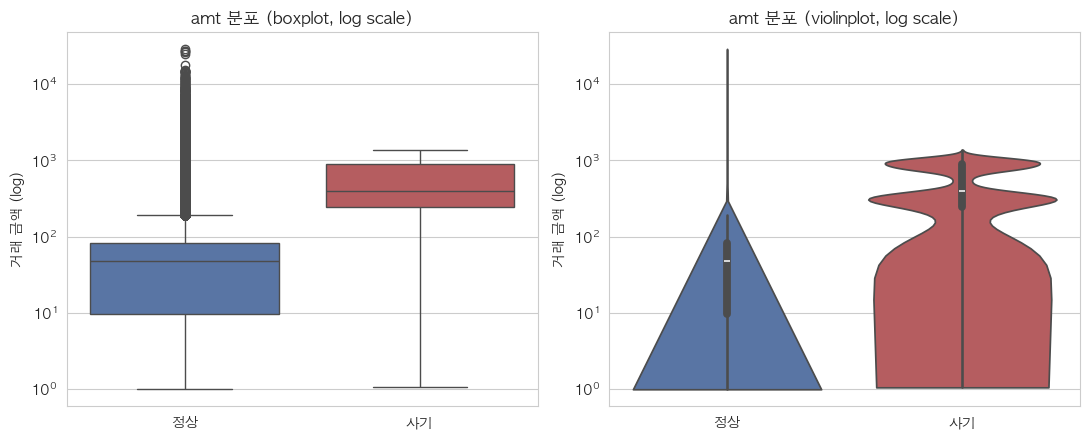

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

plot_df = df[["is_fraud", "amt"]].copy()
plot_df["label"] = plot_df["is_fraud"].map({0: "정상", 1: "사기"})

sns.boxplot(data=plot_df, x="label", y="amt", hue="label", palette=["#4C72B0", "#C44E52"], legend=False, ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("amt 분포 (boxplot, log scale)")
axes[0].set_xlabel("")
axes[0].set_ylabel("거래 금액 (log)")

sns.violinplot(data=plot_df, x="label", y="amt", hue="label", palette=["#4C72B0", "#C44E52"], legend=False, ax=axes[1], cut=0)
axes[1].set_yscale("log")
axes[1].set_title("amt 분포 (violinplot, log scale)")
axes[1].set_xlabel("")
axes[1].set_ylabel("거래 금액 (log)")

plt.tight_layout()
plt.show()

In [9]:
normal_amt = df.loc[df["is_fraud"] == 0, "amt"]
fraud_amt = df.loc[df["is_fraud"] == 1, "amt"]

u_stat, p_value = stats.mannwhitneyu(fraud_amt, normal_amt, alternative="greater")

print(f"Mann-Whitney U statistic: {u_stat:,.0f}")
print(f"p-value: {p_value:.6g}")

Mann-Whitney U statistic: 8,075,744,868
p-value: 0


**해석**

- 귀무가설(H0): 사기 거래와 정상 거래의 금액 분포에 차이가 없다.
- 대립가설(H1): 사기 거래의 금액이 정상 거래보다 크다 (one-sided).

검정 결과 p-value는 부동소수점 표현 한계로 0에 수렴할 만큼 극히 작게 나왔다(사실상 p < 1e-300 수준). 표본 크기가 130만 건에 달해 아주 작은 차이도 유의하게 나올 수 있으므로, p-value 단독이 아니라 effect size도 함께 봐야 한다 — 실제로 사기 거래의 평균 금액($531.32)은 정상 거래 평균($67.67)의 약 7.9배, 중앙값도 396.50 vs 47.28로 약 8.4배 크다. 통계적 유의성과 실질적 크기 두 근거가 모두 강하게 나타난다.

즉 "사기 거래가 정상 거래보다 금액이 크다"는 가설은 통계적으로도, 실질적으로도 지지된다. 이 결과는 Section 3에서 FN/FP 비용 구조가 왜 다른지를 뒷받침하는 핵심 근거로 사용된다.

## Section 3. 0.5 threshold 가정 검증

`threshold = 0.5`는 "FN 1건의 비용 = FP 1건의 비용"이라는 암묵적 가정 위에서만 최적이다. Section 2에서 확인한 금액 분포 차이를 근거로, 이 가정이 이 데이터에서 성립하지 않는다는 것을 숫자로 짚는다.

In [10]:
fn_mean_cost = fraud_amt.mean()
fp_fixed_cost_assumption = 5  # 고객 대응/이탈 대응에 드는 가정 비용 (달러), 실측치 아님 — README 한계점 참고

ratio = fn_mean_cost / fp_fixed_cost_assumption

print(f"FN 1건 평균 비용 (놓친 사기 거래 금액 평균): ${fn_mean_cost:,.2f}")
print(f"FP 1건 가정 비용 (고객 불편/대응 비용, 가정치): ${fp_fixed_cost_assumption:,.2f}")
print(f"FN/FP 비용 비율 (가정 기준): 약 {ratio:,.1f}배")
print(f"FN 비용 표준편차 (변동성): ${fraud_amt.std():,.2f}")

FN 1건 평균 비용 (놓친 사기 거래 금액 평균): $531.32
FP 1건 가정 비용 (고객 불편/대응 비용, 가정치): $5.00
FN/FP 비용 비율 (가정 기준): 약 106.3배
FN 비용 표준편차 (변동성): $390.56


**FN 비용과 FP 비용은 성격도, 크기도 다르다.**

| | FN (사기를 놓침) | FP (정상을 오탐) |
|---|---|---|
| 비용의 성격 | 거래 금액만큼 **직접적인 금전 손실** | 고객 불편, 문의 대응, 이탈 리스크 등 **간접 비용** |
| 비용의 크기 | 거래마다 **다름** (Section 2에서 확인한 것처럼 편차가 크고, 정상 거래보다 평균적으로 큼) | 거래 건과 무관하게 **거의 고정** (콜센터 대응 1건 비용 등으로 근사 가능) |
| 데이터 근거 | `amt` 컬럼에서 직접 측정 가능 | 이 데이터에는 없음 → 가정치 필요 (README의 한계점 참고) |

즉 FN 비용은 "거래 금액"이라는 변동성 큰 값이고, FP 비용은 "고객 대응 비용"이라는 상대적으로 고정된 값이다. 두 비용의 스케일과 분산이 다른데도 `threshold = 0.5`는 둘을 1:1로 취급한다 — 위에서 계산한 비율(FN 평균 비용이 가정 FP 비용의 수십 배)만 보아도 이 가정이 얼마나 비현실적인지 알 수 있다.

이 문제를 정량적으로 풀기 위한 비용 매트릭스와 threshold 재탐색은 4막(`04_cost_optimization.ipynb`)에서 다룬다.

## Section 4. 시간/카테고리별 사기 패턴 기초 탐색

여기서는 깊게 들어가지 않는다. "패턴이 존재하는 것 같다"는 정도만 확인하고, 실제 클러스터링을 통한 패턴 탐색은 2막(`02_clustering.ipynb`)에서 이어간다.

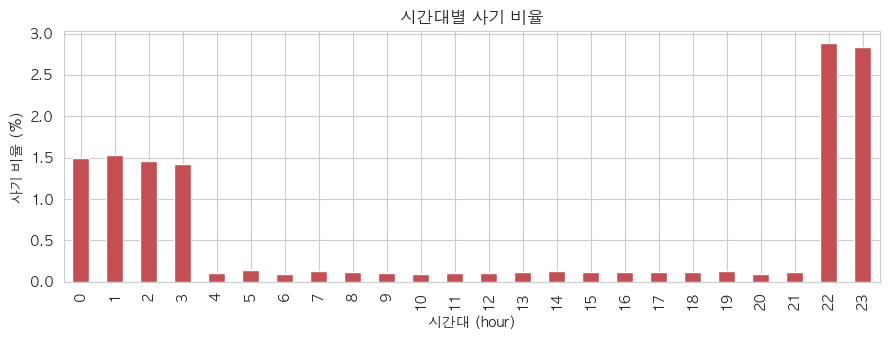

In [11]:
df["trans_hour"] = pd.to_datetime(df["trans_date_trans_time"]).dt.hour

hourly_rate = df.groupby("trans_hour")["is_fraud"].mean() * 100

fig, ax = plt.subplots(figsize=(9, 3.5))
hourly_rate.plot(kind="bar", color="#C44E52", ax=ax)
ax.set_xlabel("시간대 (hour)")
ax.set_ylabel("사기 비율 (%)")
ax.set_title("시간대별 사기 비율")
plt.tight_layout()
plt.show()

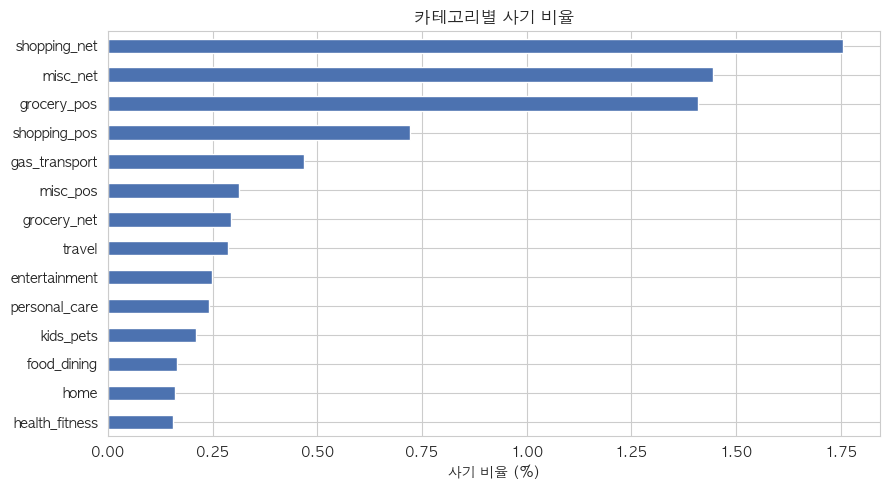

In [12]:
category_rate = (df.groupby("category")["is_fraud"].mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
category_rate.plot(kind="barh", color="#4C72B0", ax=ax)
ax.invert_yaxis()
ax.set_xlabel("사기 비율 (%)")
ax.set_ylabel("")
ax.set_title("카테고리별 사기 비율")
plt.tight_layout()
plt.show()

시간대와 카테고리 모두 사기 비율이 균일하지 않다는 정도만 확인한다. 이 편차가 얼마나 유의미한 feature가 될 수 있는지, 그리고 다른 변수들과 결합했을 때 어떤 군집이 나타나는지는 2막(`02_clustering.ipynb`)에서 본격적으로 다룬다.

## 결론

1. 사기 거래는 전체의 0.58%에 불과해 accuracy는 무의미하며, precision·recall·비용 기반 지표로 평가해야 한다.
2. Mann-Whitney U test 결과(p < 1e-300) 사기 거래의 평균 금액($531)이 정상 거래($68)의 약 8배로, 통계적으로도 실질적으로도 유의하게 크다.
3. FN 비용(변동성 큰 거래 금액)과 FP 비용(상대적으로 고정된 대응 비용)은 성격과 크기가 다르므로, `threshold = 0.5`의 "두 실수는 동일 비용" 가정은 이 데이터에서 성립하지 않는다.